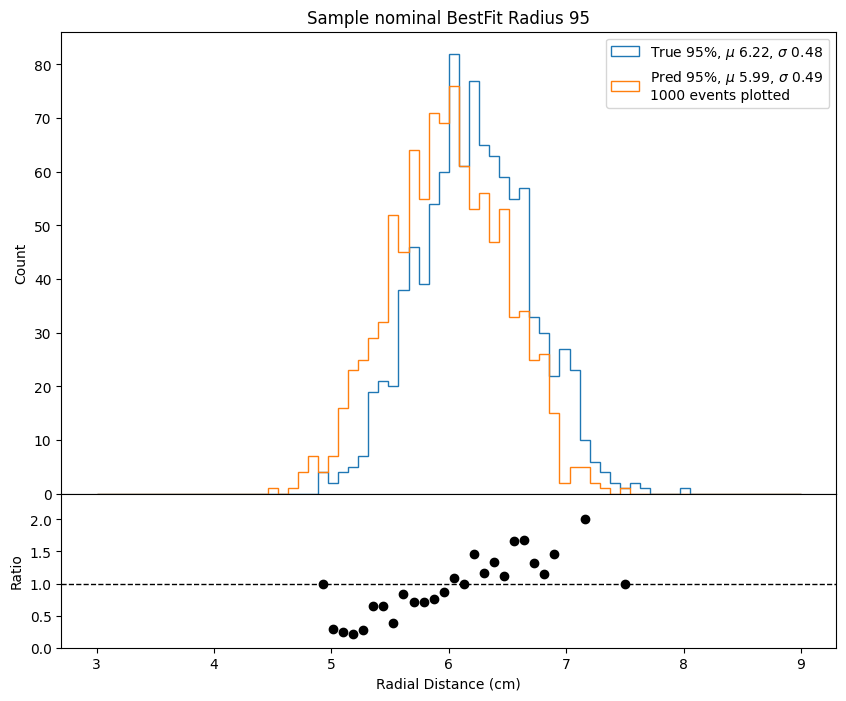

In [74]:
import numpy as np
import plot_labels
import hist
import matplotlib.pyplot as plt


results = {}
results["nominal"] = {"bestFit_r95_true": np.random.normal(6.2,0.5,1000),
                        "bestFit_r95_pred": np.random.normal(6,0.5,1000)}
# plot_hist_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))
# plot_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))

#///////////////////////////////////
# plot_ratio
#///////////////////////////////////

data = results
numerator = ("nominal","true")
denominator = ("nominal","pred")
metric = "bestFit_r95"

#///////////////////////////////////
# Start function
#///////////////////////////////////

data1 = data[numerator[0]][f"{metric}_{numerator[1]}"]
data2 = data[denominator[0]][f"{metric}_{denominator[1]}"]
formatText = plot_labels.plot_labels_select(metric, numerator, denominator)

# binning
avg = np.mean([np.mean(data1), np.mean(data2)]) # Plots center of both hists
std = np.mean([np.std(data1),np.std(data2)])

fig, axs = plt.subplots(nrows=2, figsize=(10,8), sharex=True, gridspec_kw={"hspace":0,"height_ratios":[3,1]})

#Top plot
histy1, histx1,_ = axs[0].hist(data1, bins = formatText["bins"], histtype="step",
                               range = [formatText["lower"],formatText["upper"]],
                               label = f"{formatText['label1']}, $\mu$ {np.mean(data1):.2f}, $\sigma$ {np.std(data1):.2f}")
histy2, histx2,_ = axs[0].hist(data2, bins = formatText["bins"], histtype="step",
                               range = [formatText["lower"],formatText["upper"]],
                               label = f"{formatText['label2']}, $\mu$ {np.mean(data2):.2f}, $\sigma$ {np.std(data2):.2f}\n{len(data1)} events plotted")
#Ratio plot
ratiox = np.asarray( [(x + histx1[i - 1])/2 for i, x in enumerate(histx1) if i > 0] )
ratioy = np.asarray( [histy1[i]/histy2[i] if histy1[i] != 0 and histy2[i] != 0 else -1 for i in range(len(histy1))] ) #This is how its always meant to be
#hist output and division is always >= 0 so use -1 as filter flag
ratiox = ratiox[ratioy!=-1]
ratioy = ratioy[ratioy!=-1]
axs[1].scatter(ratiox,ratioy, color="black")
axs[1].axhline(y=1, linestyle="--", linewidth="1", color="black")

#Format
axs[0].set_title(formatText["title"])
axs[1].set_xlabel(formatText["x_axis"])
axs[0].set_ylabel("Count")
axs[1].set_ylabel("Ratio")
axs[0].legend()
axs[1].set_ylim(0,2.4)



# fig.savefig("best"+formatText["saveas"])
plt.show()
plt.close()

In [ ]:

results = {}
results["nominal"] = {"bestFit_r95_true": np.random.normal(6.2,0.5,1000),
                        "bestFit_r95_pred": np.random.normal(6,0.5,1000)}
# plot_hist_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))
# plot_ratio(results, "bestFit_r95", ("nominal","true"), ("nominal","pred"))

#///////////////////////////////////
# plot_ratio
#///////////////////////////////////

data = results
numerator = ("nominal","true")
denominator = ("nominal","pred")
metric = "bestFit_r95"

#///////////////////////////////////
# Start function
#///////////////////////////////////

data1 = data[numerator[0]][f"{metric}_{numerator[1]}"]
data2 = data[denominator[0]][f"{metric}_{denominator[1]}"]
formatText = plot_labels.plot_labels_select(metric, numerator, denominator)

# binning
avg = np.mean([np.mean(data1), np.mean(data2)]) # Plots center of both hists
std = np.mean([np.std(data1),np.std(data2)])

fig, axs = plt.subplots(nrows=2, figsize=(10,8), sharex=True, gridspec_kw={"hspace":0,"height_ratios":[3,1]})



#Top plot
histy1, histx1,_ = axs[0].hist(data1, bins = formatText["bins"], histtype="step",
                               range = [formatText["lower"],formatText["upper"]],
                               label = f"{formatText['label1']}, $\mu$ {np.mean(data1):.2f}, $\sigma$ {np.std(data1):.2f}")
histy2, histx2,_ = axs[0].hist(data2, bins = formatText["bins"], histtype="step",
                               range = [formatText["lower"],formatText["upper"]],
                               label = f"{formatText['label2']}, $\mu$ {np.mean(data2):.2f}, $\sigma$ {np.std(data2):.2f}\n{len(data1)} events plotted")
#Ratio plot
ratiox = np.asarray( [(x + histx1[i - 1])/2 for i, x in enumerate(histx1) if i > 0] )
ratioy = np.asarray( [histy1[i]/histy2[i] if histy1[i] != 0 and histy2[i] != 0 else -1 for i in range(len(histy1))] ) #This is how its always meant to be
#hist output and division is always >= 0 so use -1 as filter flag
ratiox = ratiox[ratioy!=-1]
ratioy = ratioy[ratioy!=-1]
axs[1].scatter(ratiox,ratioy, color="black")
axs[1].axhline(y=1, linestyle="--", linewidth="1", color="black")

#Format
axs[0].set_title(formatText["title"])
axs[1].set_xlabel(formatText["x_axis"])
axs[0].set_ylabel("Count")
axs[1].set_ylabel("Ratio")
axs[0].legend()
axs[1].set_ylim(0,2.4)



# fig.savefig("best"+formatText["saveas"])
plt.show()
plt.close()